In [29]:
from naive_adc_circuit import naive_circuit
from hardware_aware_circuit import ha_circuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import generate_preset_pass_manager
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
plt.rcParams.update({'font.size': 15})

In [8]:
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    instance='crn:v1:bluemix:public:quantum-computing:eu-de:a/cb804b30dfcb48b890393bfd6e41e9c2:a59c3379-0cf7-47fe-adf1-553bf24e0c35::'
)

In [11]:
#n = [2, 3, 4, 5, 10, 12, 16, 20, 25, 30, 35, 40, 45, 50]
n = [2, 5, 10, 15, 20, 30, 40, 50]
# n = [2, 3, 4, 5, 10, 12, 16, 20]
tlist = np.linspace(0, 25, 100)
excited = ["0"]
k = 1
dissipation = True
backend = service.backend("ibm_basquecountry")
N = 100 # Number of transpiler samplings

best_naive_isa_qcs = []
virtual_naive_tqds, virtual_ha_tqds = [], []
mean_naive_isa_tqds, mean_ha_isa_tqds = [], []
min_naive_isa_tqds = []
std_naive_isa_tqds, std_ha_isa_tqds = [], []
for size in n:
    J = [1/4]*(size-1)
    gamma = [J[0]/4]*size
    qc = naive_circuit(J, gamma, size, excited, k, dissipation)
    virtual_naive_tqds.append(qc.decompose(reps = 2).depth(lambda instr: len(instr.qubits) > 1))

    ha_qc, init_layout = ha_circuit(J, gamma, size, excited, k, backend, dissipation)
    virtual_ha_tqds.append(ha_qc.decompose(reps = 2).depth(lambda instr: len(instr.qubits) > 1))

    naive_isa_tqds, ha_isa_tqds = [], []
    naive_isa_qcs = []
    for i in range(N):
        naive_pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
        naive_isa_qc = naive_pm.run(qc)
        naive_isa_qcs.append(naive_isa_qc)
        naive_isa_tqds.append(naive_isa_qc.depth(lambda instr: len(instr.qubits) > 1))
                                        
        ha_pm = generate_preset_pass_manager(optimization_level = 3, backend = backend, initial_layout = init_layout, routing_method="none")
        ha_isa_qc = ha_pm.run(ha_qc)
        ha_isa_tqds.append(ha_isa_qc.depth(lambda instr: len(instr.qubits) > 1))

    mean_naive_isa_tqds.append(np.mean(naive_isa_tqds))
    std_naive_isa_tqds.append(np.std(naive_isa_tqds))
    min_naive_isa_tqds.append(np.min(naive_isa_tqds))

    idx_min = naive_isa_tqds.index(np.min(naive_isa_tqds))
    best_naive_isa_qcs.append(naive_isa_qcs[idx_min])

    mean_ha_isa_tqds.append(np.mean(ha_isa_tqds))
    std_ha_isa_tqds.append(np.std(ha_isa_tqds))

In [ ]:
ha_qc.draw('mpl', fold = -1)

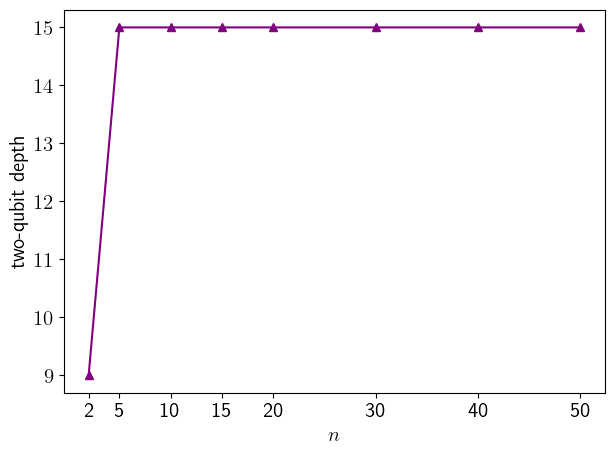

In [31]:
plt.plot(n, virtual_naive_tqds, marker = '^', color = 'purple', linestyle = "solid", label = 'Naive virtual circuit')
# plt.plot(n, mean_naive_isa_tqds, marker = '^', color = 'purple', label = '(Average) Naive ISA circuit')
# plt.plot(n, mean_naive_isa_tqds, marker = '^', color = 'purple', label = 'Naive ISA circuit')
# upper_bound = np.array(mean_naive_isa_tqds) + np.array(std_naive_isa_tqds)
# lower_bound = np.array(mean_naive_isa_tqds) - np.array(std_naive_isa_tqds)
# plt.fill_between(n, lower_bound, upper_bound, color = "purple", alpha = 0.1)

# plt.plot(n, min_naive_isa_tqds, marker = '*', color = 'purple', alpha = 0.3, label = 'Best Naive ISA circuit')

# plt.plot(n, virtual_ha_tqds, marker = 's', color = 'orange', linestyle = "dashed", alpha = 0.5, label = 'HA virtual circuit')
# plt.plot(n, mean_ha_isa_tqds, marker = 's', color = 'orange', label = 'HA ISA circuit')
# upper_bound = np.array(mean_ha_isa_tqds) + np.array(std_ha_isa_tqds)
# lower_bound = np.array(mean_ha_isa_tqds) - np.array(std_ha_isa_tqds)
# plt.fill_between(n, lower_bound, upper_bound, color = "orange", alpha = 0.1)
plt.xlabel("$n$")
plt.ylabel("two-qubit depth")
# plt.legend(frameon = False)
plt.xticks(n, n)
plt.tight_layout()
plt.savefig("[RUBEN]tqd_scaling.png", bbox_inches='tight', transparent = True)
plt.show()

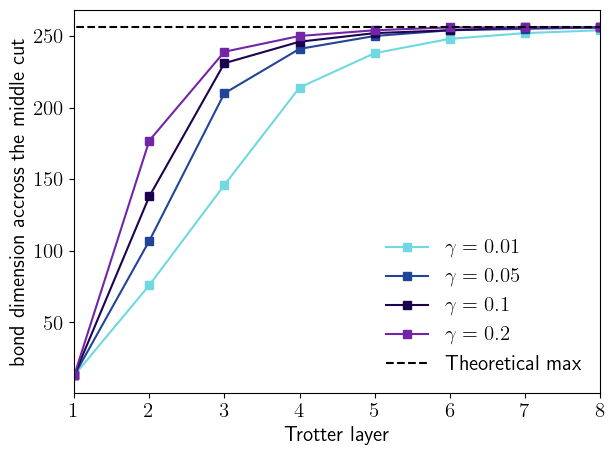

In [21]:
import pandas as pd
chis = pd.read_csv('layer_growth_n5.csv')
gammas = [0.01, 0.05, 0.1, 0.2]
layers = range(1, 9, 1)
colors = ['#70d8e0', "#214598", "#1d034d", "#7325a8"]
markers = ['^', 's', 'o', '*']
for (idx, g) in enumerate(gammas):
    data = chis[f'gamma_{g}']
    plt.plot(layers, data, marker = 's', color = colors[idx], label = f'$\\gamma = {g}$')
plt.plot(np.linspace(0,9, 100), 256*np.ones(100), linestyle = "dashed", color = "black", label = "Theoretical max")
plt.xlabel("Trotter layer")
plt.ylabel("bond dimension accross the middle cut")
plt.legend(frameon = False)
plt.xlim([1,8])
plt.tight_layout()
plt.savefig("[RUBEN]bond_dimension_scaling.png", bbox_inches='tight', transparent = True)
plt.show()

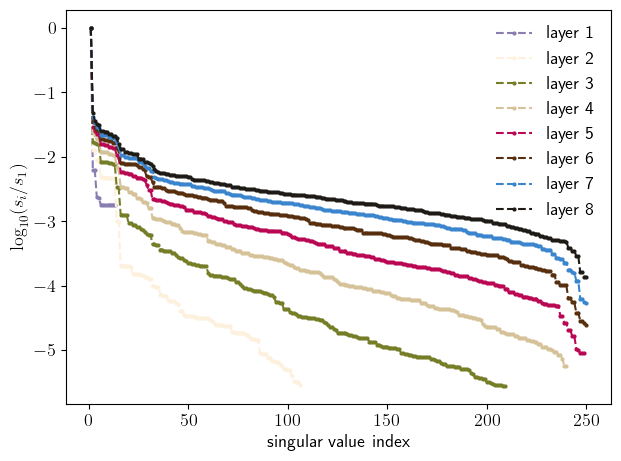

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# The CSV already has a header row, so pandas picks up column names automatically
df = pd.read_csv("Fii_spectrum.csv")
colors = ["#897db2", "#fdf0dc", "#757d27", "#d5c298", "#ba0754", "#572f0f", "#3a85cd", "#1e1a16"]

fig, ax = plt.subplots()

for (idx,layer) in enumerate(sorted(df["layer"].unique())):
    sub = df[df["layer"] == layer]          # rows belonging to this layer
    ax.plot(sub["index"], sub["log10_s_over_s1"],
            marker="o", markersize=2, linestyle = 'dashed', color = colors[idx], label=f"layer {int(layer)}")

ax.set_xlabel("singular value index")
ax.set_ylabel(r"$\log_{10}(s_i / s_1)$")
ax.legend(frameon = False)
fig.tight_layout()
fig.savefig("[RUBEN]spectrum_F.png", bbox_inches='tight', transparent = True)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# The CSV already has a header row, so pandas picks up column names automatically
df = pd.read_csv("Fii_spectrum.csv")

fig, ax = plt.subplots(figsize=(7, 5))

for layer in sorted(df["layer"].unique()):
    sub = df[df["layer"] == layer]          # rows belonging to this layer
    ax.plot(sub["index"], sub["log10_s_over_s1"],
            marker="o", markersize=3, label=f"layer {int(layer)}")

ax.set_xlabel("singular value index")
ax.set_ylabel(r"$\log_{10}(s_i / s_1)$")
ax.set_title("$F_{ii}$ operator-Schmidt spectrum by layer")
ax.legend()
fig.tight_layout()
fig.savefig("Fii_spectrum_by_layer_reloaded.png", dpi=150)
plt.show()

In [ ]:
import pandas as pd
tns = pd.read_csv('layer_growth_n5.csv', usecols = ["pop_q0_mpdo"])
all_trotter_tn = { f'k = {trotter}' : None for trotter in k }
for (idx, i) in enumerate(range(0, len(tns), 11)):
    all_trotter_tn[f"k = {k[idx]}"] = tns[i:i+11].to_numpy()
instants_tns = pd.read_csv('validate_mpdo_population.csv', usecols = ["t"])[0:11].to_numpy()


In [ ]:
tns = pd.read_csv('layer_growth_n5.csv')
tns

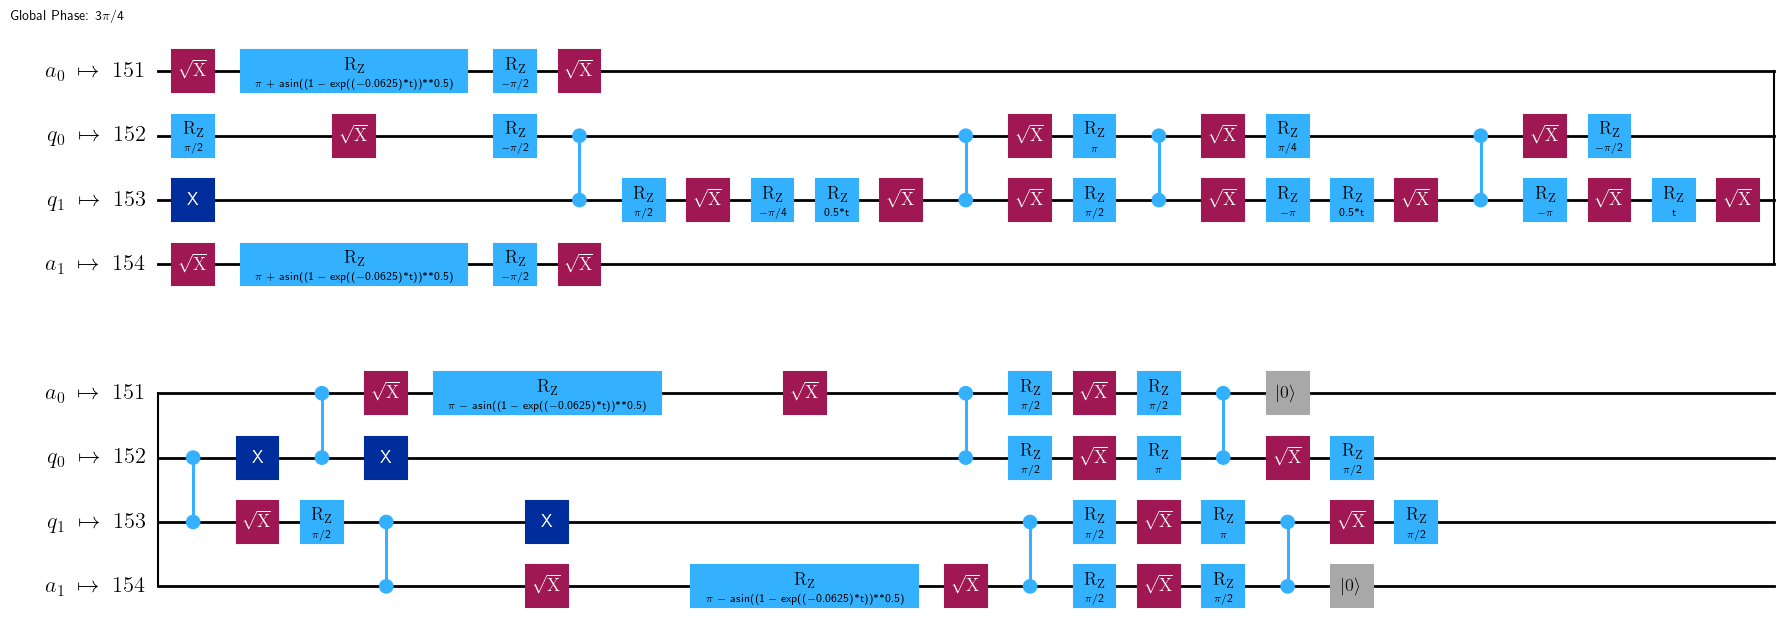

In [5]:
best_naive_isa_qcs[0].draw('mpl', idle_wires = False)

In [ ]:
from plot_initial_layout import plot_layouts
fig, axes = plot_layouts(best_naive_isa_qcs[0:8], backend, titles=[f"n = {s}" for s in n[0:9]])
fig.savefig("[COLORED]initial_layouts_in_BEST_naive_adc_ibm_basquecountry.png", transparent = True, bbox_inches='tight')